# Simple Trading Rule

In [28]:
import psutil
from sysdata.sim.csv_futures_sim_data import csvFuturesSimData
import matplotlib.pyplot as plt
%matplotlib inline

Work up a minimum example of a trend following system

Let's get some data

We can get data from various places; however for now we're going to use
prepackaged 'legacy' data stored in csv files

In [29]:
data = csvFuturesSimData()
data

csvFuturesSimData object with 252 instruments

We get stuff out of data with methods

In [30]:
print(data.get_instrument_list())
print(data.get_raw_price("COCOA").tail(5))

['RUSSELL', 'SOFR', 'CNH', 'ALUMINIUM', 'GASOIL', 'CAD', 'COAL-GEORDIE', 'CAD5', 'EUROSTX200-LARGE', 'NIKKEI400', 'HANGENT', 'TIN_LME', 'EU-TECH', 'GASOILINE_micro', 'FTSEVIET', 'MIB', 'FED', 'EU-CONSTRUCTION', 'AEX', 'US10', 'HANGENT_mini', 'COPPER', 'MSCIEAFA', 'EU-RETAIL', 'COFFEE', 'MXP', 'SOYOIL', 'EU-MID', 'WHEY', 'LUMBER-new', 'DAX', 'CAC', 'EU-CHEM', 'EU-OIL', 'JPY', 'US30', 'TOPIX', 'EURIBOR-ICE', 'EUROSTX-SMALL', 'OATIES', 'SGD_mini', 'HANG_mini', 'US-STAPLES', 'JP-REALESTATE', 'SILVER', 'SP500', 'BONO', 'EU-REALESTATE', 'SHATZ', 'SOYMEAL', 'MILKWET', 'EU-HEALTH', 'BRENT-LAST', 'COPPER-micro', 'PALLAD', 'SPI200', 'HANGTECH', 'EU-AUTO', 'MSCIASIA', 'VIX_mini', 'VIX', 'EU-HOUSE', 'US-ENERGY', 'KRWUSD', 'IBEX', 'EU-TRAVEL', 'SUGAR_WHITE', 'US3', 'LIVECOW', 'NASDAQ_micro', 'GICS', 'FEEDCOW', 'CRUDE_W_micro', 'MSCITAIWAN', 'US-PROPERTY', 'FTSE250', 'GAS_US', 'CZK', 'CORN_mini', 'CAD2', 'EU-DJ-OIL', 'SP500_micro', 'FTSECHINAH', 'STEEL', 'CLP', 'LEANHOG', 'CHF_micro', 'WHEAT_mini', 

data can also behave in a dict like manner (though it's not a dict)

In [31]:
data['SP500']

index
1982-09-14 23:00:00     618.40
1982-09-15 23:00:00     618.90
1982-09-16 23:00:00     618.25
1982-09-17 23:00:00     617.35
1982-09-20 23:00:00     618.15
                        ...   
2024-02-29 16:00:00    5083.50
2024-02-29 17:00:00    5090.50
2024-02-29 18:00:00    5095.00
2024-02-29 19:00:00    5094.50
2024-02-29 20:00:00    5095.50
Name: price, Length: 35715, dtype: float64

In [32]:
data.keys()

['RUSSELL',
 'SOFR',
 'CNH',
 'ALUMINIUM',
 'GASOIL',
 'CAD',
 'COAL-GEORDIE',
 'CAD5',
 'EUROSTX200-LARGE',
 'NIKKEI400',
 'HANGENT',
 'TIN_LME',
 'EU-TECH',
 'GASOILINE_micro',
 'FTSEVIET',
 'MIB',
 'FED',
 'EU-CONSTRUCTION',
 'AEX',
 'US10',
 'HANGENT_mini',
 'COPPER',
 'MSCIEAFA',
 'EU-RETAIL',
 'COFFEE',
 'MXP',
 'SOYOIL',
 'EU-MID',
 'WHEY',
 'LUMBER-new',
 'DAX',
 'CAC',
 'EU-CHEM',
 'EU-OIL',
 'JPY',
 'US30',
 'TOPIX',
 'EURIBOR-ICE',
 'EUROSTX-SMALL',
 'OATIES',
 'SGD_mini',
 'HANG_mini',
 'US-STAPLES',
 'JP-REALESTATE',
 'SILVER',
 'SP500',
 'BONO',
 'EU-REALESTATE',
 'SHATZ',
 'SOYMEAL',
 'MILKWET',
 'EU-HEALTH',
 'BRENT-LAST',
 'COPPER-micro',
 'PALLAD',
 'SPI200',
 'HANGTECH',
 'EU-AUTO',
 'MSCIASIA',
 'VIX_mini',
 'VIX',
 'EU-HOUSE',
 'US-ENERGY',
 'KRWUSD',
 'IBEX',
 'EU-TRAVEL',
 'SUGAR_WHITE',
 'US3',
 'LIVECOW',
 'NASDAQ_micro',
 'GICS',
 'FEEDCOW',
 'CRUDE_W_micro',
 'MSCITAIWAN',
 'US-PROPERTY',
 'FTSE250',
 'GAS_US',
 'CZK',
 'CORN_mini',
 'CAD2',
 'EU-DJ-OIL',
 'S

... however this will only access prices
(note these prices have already been backadjusted for rolls)

We have extra futures data here

In [33]:
data.get_instrument_raw_carry_data("COCOA").tail(6)

,PRICE,CARRY,PRICE_CONTRACT,CARRY_CONTRACT
index,,,,
2024-02-29 13:00:00,5789.0,6112.0,20240700,20240500
2024-02-29 14:00:00,5780.0,6087.0,20240700,20240500
2024-02-29 15:00:00,5710.0,5994.0,20240700,20240500
2024-02-29 16:00:00,5739.0,6066.0,20240700,20240500
2024-02-29 17:00:00,5751.0,6071.0,20240700,20240500
2024-02-29 18:00:00,5763.0,6088.0,20240700,20240500


Technical note: csvFuturesSimData inherits from FuturesData which itself inherits from simData
The chain is 'data specific' <- 'asset class specific' <- 'generic'

Let's create a simple trading rule

No capping or scaling

In [34]:
import pandas as pd
from sysquant.estimators.vol import robust_vol_calc


def calc_ewmac_forecast(price, Lfast, Lslow=None):
    """
    Calculate the ewmac trading rule forecast, given a price and EWMA speeds
    Lfast, Lslow and vol_lookback

    """
    # price: This is the stitched price series
    # We can't use the price of the contract we're trading, or the volatility
    # will be jumpy
    # And we'll miss out on the rolldown. See
    # https://qoppac.blogspot.com/2015/05/systems-building-futures-rolling.html

    price = price.resample("1B").last()

    if Lslow is None:
        Lslow = 4 * Lfast

    # We don't need to calculate the decay parameter, just use the span
    # directly
    fast_ewma = price.ewm(span=Lfast).mean()
    slow_ewma = price.ewm(span=Lslow).mean()
    raw_ewmac = fast_ewma - slow_ewma
    vol = robust_vol_calc(price.diff())
    return raw_ewmac / vol


Try it out

(this isn't properly scaled at this stage of course)


In [39]:
instrument_code = 'GOLD'
price = data.daily_prices(instrument_code)
ewmac = calc_ewmac_forecast(price, 32, 128)
ewmac.columns = ['forecast']
ewmac.tail(5)

index
2024-02-23    0.658338
2024-02-26    0.662980
2024-02-27    0.664563
2024-02-28    0.680650
2024-02-29    0.724845
Freq: B, Name: price, dtype: float64

Text(0.5, 0, 'Time')

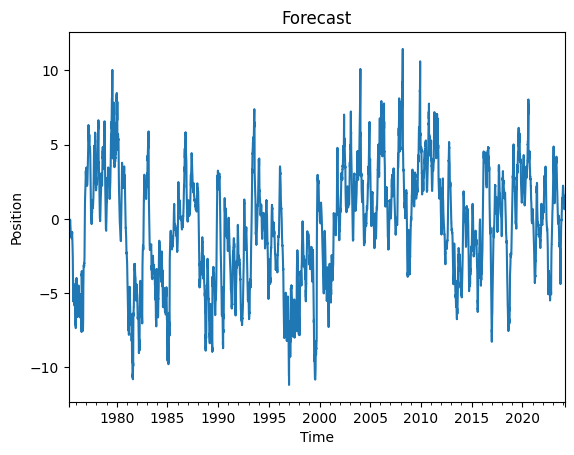

In [40]:
ewmac.plot();
plt.title('Forecast')
plt.ylabel('Position')
plt.xlabel('Time')


Did we make money?


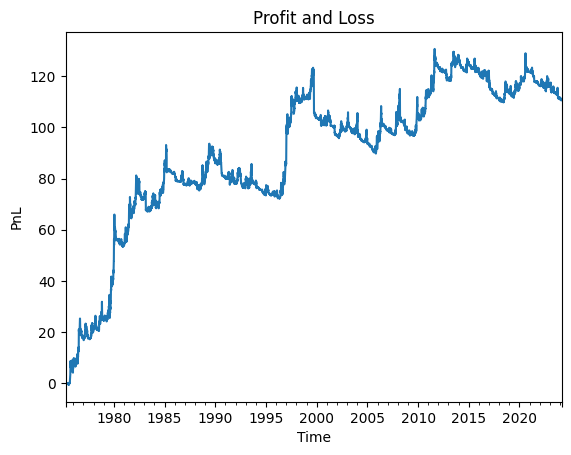

In [41]:
from systems.accounts.account_forecast import pandl_for_instrument_forecast
account = pandl_for_instrument_forecast(forecast=ewmac, price = price)
account.curve().plot();
plt.title('Profit and Loss')
plt.ylabel('PnL')
plt.xlabel('Time');

In [43]:
account.percent.stats()

[[('min', '-7.932'),
  ('max', '5.548'),
  ('median', '0'),
  ('mean', '0.008684'),
  ('std', '0.4498'),
  ('skew', '-1.192'),
  ('ann_mean', '2.223'),
  ('ann_std', '7.196'),
  ('sharpe', '0.3089'),
  ('sortino', '0.3367'),
  ('avg_drawdown', '-13.28'),
  ('time_in_drawdown', '0.986'),
  ('calmar', '0.06633'),
  ('avg_return_to_drawdown', '0.1674'),
  ('avg_loss', '-0.2578'),
  ('avg_gain', '0.254'),
  ('gaintolossratio', '0.9851'),
  ('profitfactor', '1.074'),
  ('hitrate', '0.5217'),
  ('t_stat', '2.181'),
  ('p_value', '0.02919')],
 ('You can also plot / print:',
  ['rolling_ann_std', 'drawdown', 'curve', 'percent'])]